# Awinda: full (hip–knee–ankle) vs single-joint models

Compare ID prediction accuracy from:

- **Full / multi-joint**: `process_awinda.npz` (one TCN → all 6 sagittal channels)
- **Per-joint**: `process_awinda_per_joint_{hip,knee,ankle}.npz` (separate unilateral models)

For each joint group (hip / knee / ankle), test whether the **single-joint** model performs **worse** than the full model on matched `(trial, channel)` pairs:

- RMSE: one-sided Wilcoxon / paired t-test with H1: single > full
- R²: one-sided Wilcoxon / paired t-test with H1: single < full

§1b audits outlier single-joint trials (inspection only — nothing is dropped from the comparison).

Set `RIGHT_ONLY` in the config cell to use **right-side channels only** (`True`) or **both L and R** (`False`).

Run `process_awinda.ipynb` and `process_awinda_per_joint.ipynb` first if caches are missing.

Paper-ready tables/figures go to `analysis/paper_outputs/awinda/` (or `awinda_right/` when `RIGHT_ONLY=True`) — CSV + LaTeX, PDF + PNG @ 300 dpi.


In [49]:
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
FULL_CACHE = CACHE_DIR / 'process_awinda.npz'
PER_JOINT_CACHES = {
    'hip': CACHE_DIR / 'process_awinda_per_joint_hip.npz',
    'knee': CACHE_DIR / 'process_awinda_per_joint_knee.npz',
    'ankle': CACHE_DIR / 'process_awinda_per_joint_ankle.npz',
}

JOINT_CHANNELS_ALL = {
    'hip': ['hip_flexion_r', 'hip_flexion_l'],
    'knee': ['knee_angle_r', 'knee_angle_l'],
    'ankle': ['ankle_angle_r', 'ankle_angle_l'],
}

# True → right-side (_r) channels only; False → both L and R.
RIGHT_ONLY = False

JOINT_CHANNELS = {
    j: ([c for c in chs if c.endswith('_r')] if RIGHT_ONLY else list(chs))
    for j, chs in JOINT_CHANNELS_ALL.items()
}
ACTIVE_CHANNELS = [c for chs in JOINT_CHANNELS.values() for c in chs]

# Drop known-bad / paper-excluded trials from paired tests (empty set = keep all).
EXCLUDE_TRIALS = {
    'AB05_Maria::LG_0p8mps',  # consistently poor ID across pipelines
}

ALPHA = 0.05
PAPER_SUBDIR = 'awinda' + ('_right' if RIGHT_ONLY else '')

print('Full cache:', FULL_CACHE, '| exists=', FULL_CACHE.is_file())
for j, p in PER_JOINT_CACHES.items():
    print(f'  {j:5s}', p.name, '| exists=', p.is_file())
print(f'RIGHT_ONLY={RIGHT_ONLY} → channels={ACTIVE_CHANNELS}')
print('EXCLUDE_TRIALS:', sorted(EXCLUDE_TRIALS) if EXCLUDE_TRIALS else [])
print(f'Paper outputs → analysis/paper_outputs/{PAPER_SUBDIR}/')


Full cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz | exists= True
  hip   process_awinda_per_joint_hip.npz | exists= True
  knee  process_awinda_per_joint_knee.npz | exists= True
  ankle process_awinda_per_joint_ankle.npz | exists= True
RIGHT_ONLY=False → channels=['hip_flexion_r', 'hip_flexion_l', 'knee_angle_r', 'knee_angle_l', 'ankle_angle_r', 'ankle_angle_l']
EXCLUDE_TRIALS: ['AB05_Maria::LG_0p8mps']
Paper outputs → analysis/paper_outputs/awinda/


In [50]:
def _read_detail_df(npz) -> pd.DataFrame:
    if 'detail_df' not in npz.files:
        raise KeyError(f'No detail_df in cache; keys={sorted(npz.files)[:20]}...')
    return pd.read_json(io.StringIO(str(npz['detail_df'].item())), orient='split')


def load_full_detail(path: Path = FULL_CACHE) -> Tuple[pd.DataFrame, List[str]]:
    if not path.is_file():
        raise FileNotFoundError(path)
    npz = np.load(str(path), allow_pickle=True)
    det = _read_detail_df(npz)
    channels = [str(c) for c in npz['channels']]
    det = det.copy()
    det['model'] = 'full'
    det[['subject', 'condition']] = det['trial'].str.split('::', n=1, expand=True)
    return det, channels


def load_per_joint_detail(paths: Dict[str, Path] = PER_JOINT_CACHES) -> pd.DataFrame:
    frames = []
    for joint, path in paths.items():
        if not path.is_file():
            print(f'[WARN] missing {path.name} — skip {joint}')
            continue
        npz = np.load(str(path), allow_pickle=True)
        det = _read_detail_df(npz)
        det = det.copy()
        det['model'] = 'single'
        det['joint'] = joint
        det[['subject', 'condition']] = det['trial'].str.split('::', n=1, expand=True)
        frames.append(det)
    if not frames:
        raise FileNotFoundError('No per-joint caches found')
    return pd.concat(frames, ignore_index=True)


full_detail, FULL_CHANNELS = load_full_detail()
single_detail = load_per_joint_detail()

# Attach joint label on full-model rows from channel name
def channel_to_joint(ch: str) -> str:
    if ch.startswith('hip_'):
        return 'hip'
    if ch.startswith('knee_'):
        return 'knee'
    if ch.startswith('ankle_'):
        return 'ankle'
    raise ValueError(ch)

full_detail = full_detail.copy()
full_detail['joint'] = full_detail['channel'].map(channel_to_joint)

# Restrict to active side(s) from RIGHT_ONLY in the config cell.
n_full_before, n_single_before = len(full_detail), len(single_detail)
full_detail = full_detail[full_detail['channel'].isin(ACTIVE_CHANNELS)].copy()
single_detail = single_detail[single_detail['channel'].isin(ACTIVE_CHANNELS)].copy()
FULL_CHANNELS = [c for c in FULL_CHANNELS if c in ACTIVE_CHANNELS]

print(f'RIGHT_ONLY={RIGHT_ONLY}: full {n_full_before}→{len(full_detail)}, '
      f'single {n_single_before}→{len(single_detail)}')
print(f'Full detail rows: {len(full_detail)} | channels={FULL_CHANNELS}')
print(f'Single detail rows: {len(single_detail)} | joints={sorted(single_detail["joint"].unique())}')
display(pd.concat([
    full_detail.groupby('joint').size().rename('full_n'),
    single_detail.groupby('joint').size().rename('single_n'),
], axis=1))


RIGHT_ONLY=False: full 240→240, single 240→240
Full detail rows: 240 | channels=['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r', 'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l']
Single detail rows: 240 | joints=['ankle', 'hip', 'knee']


,full_n,single_n
joint,,
ankle,80,80
hip,80,80
knee,80,80


## 1. Paired metrics table

Merge on `(trial, channel)`. ΔRMSE = single − full (positive ⇒ single worse). ΔR² = single − full (negative ⇒ single worse).


In [51]:
keys = ['trial', 'channel', 'joint', 'subject', 'condition']
full_m = full_detail[keys + ['rmse_nmpkg', 'r2_nmpkg']].rename(
    columns={'rmse_nmpkg': 'rmse_full', 'r2_nmpkg': 'r2_full'}
)
single_m = single_detail[keys + ['rmse_nmpkg', 'r2_nmpkg']].rename(
    columns={'rmse_nmpkg': 'rmse_single', 'r2_nmpkg': 'r2_single'}
)

paired = full_m.merge(single_m, on=keys, how='inner', validate='one_to_one')
paired['delta_rmse'] = paired['rmse_single'] - paired['rmse_full']
paired['delta_r2'] = paired['r2_single'] - paired['r2_full']
paired['single_worse_rmse'] = paired['delta_rmse'] > 0
paired['single_worse_r2'] = paired['delta_r2'] < 0

n_before = len(paired)
if EXCLUDE_TRIALS:
    paired = paired[~paired['trial'].isin(EXCLUDE_TRIALS)].copy()
print(f'Paired rows: {n_before} → {len(paired)} after excludes')
print(f'Trials in paired set: {paired["trial"].nunique()}')

summary_joint = paired.groupby('joint').agg(
    n=('trial', 'count'),
    rmse_full_mean=('rmse_full', 'mean'),
    rmse_single_mean=('rmse_single', 'mean'),
    delta_rmse_median=('delta_rmse', 'median'),
    delta_rmse_mean=('delta_rmse', 'mean'),
    frac_single_worse_rmse=('single_worse_rmse', 'mean'),
    r2_full_mean=('r2_full', 'mean'),
    r2_single_mean=('r2_single', 'mean'),
    delta_r2_median=('delta_r2', 'median'),
    delta_r2_mean=('delta_r2', 'mean'),
    frac_single_worse_r2=('single_worse_r2', 'mean'),
).reset_index()
display(summary_joint.round(4))

CACHE_DIR.mkdir(parents=True, exist_ok=True)
paired_csv = CACHE_DIR / 'compare_awinda_full_vs_per_joint_paired.csv'
paired.to_csv(paired_csv, index=False)
print(f'Saved → {paired_csv}')


Paired rows: 240 → 234 after excludes
Trials in paired set: 39


,joint,n,rmse_full_mean,rmse_single_mean,delta_rmse_median,delta_rmse_mean,frac_single_worse_rmse,r2_full_mean,r2_single_mean,delta_r2_median,delta_r2_mean,frac_single_worse_r2
0,ankle,78,0.1594,0.2042,0.0356,0.0448,0.8077,0.9305,0.8672,-0.0351,-0.0632,0.8590
1,hip,78,0.1487,0.1637,0.0211,0.0150,0.6410,0.8363,0.7510,-0.0604,-0.0853,0.6923
2,knee,78,0.1327,0.1645,0.0245,0.0318,0.7564,0.7903,0.7152,-0.0374,-0.0751,0.6667


Saved → /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_awinda_full_vs_per_joint_paired.csv


## 1b. Single-joint outlier audit

Flag channel-rows where the **single-joint** model is clearly worse than peers / the full model:

| class | rule |
|---|---|
| `single_specific` | full still decent (R²≥0.7, RMSE≤0.25) but single fails (R²&lt;0.55 or RMSE&gt;0.28 or large Δ) |
| `both_bad` | full and single both poor → likely data/IK/ID, not per-joint-only |
| `ok` | everything else |

Sync is usually fine on these (high angle-xcorr); failures cluster on **RD_0p8mps** and **AB01/AB02 knee**. Listed for inspection only — **do not exclude** from caches or paired tests.


In [52]:
def _classify_pair(r: pd.Series) -> str:
    full_ok = (r['r2_full'] >= 0.7) and (r['rmse_full'] <= 0.25)
    full_bad = (r['r2_full'] < 0.5) or (r['rmse_full'] > 0.28)
    single_bad = (
        (r['r2_single'] < 0.55)
        or (r['rmse_single'] > 0.28)
        or (r['delta_r2'] < -0.30)
        or (r['delta_rmse'] > 0.12)
    )
    if single_bad and full_ok:
        return 'single_specific'
    if single_bad and full_bad:
        return 'both_bad'
    if single_bad:
        return 'single_bad_full_med'
    return 'ok'


paired_qc = paired.copy()
paired_qc['cls'] = paired_qc.apply(_classify_pair, axis=1)

print('Channel-row classes:')
display(paired_qc['cls'].value_counts().rename('n').to_frame())

print('\nBy condition (bad = not ok):')
display(pd.crosstab(paired_qc['condition'], paired_qc['cls'] != 'ok', margins=True)
        .rename(columns={False: 'ok', True: 'bad'}))

print('\nBy subject (bad = not ok):')
display(pd.crosstab(paired_qc['subject'], paired_qc['cls'] != 'ok', margins=True)
        .rename(columns={False: 'ok', True: 'bad'}))

cols = [
    'trial', 'joint', 'channel', 'rmse_full', 'rmse_single',
    'r2_full', 'r2_single', 'delta_rmse', 'delta_r2', 'cls',
]
print('\n=== single_specific (full OK, single fails — per-joint pipeline / model) ===')
display(
    paired_qc[paired_qc['cls'] == 'single_specific'][cols]
    .sort_values(['joint', 'r2_single'])
    .reset_index(drop=True)
    .round(4)
)
print('\n=== both_bad (likely shared data/IK/ID issue) ===')
display(
    paired_qc[paired_qc['cls'] == 'both_bad'][cols]
    .sort_values(['joint', 'r2_single'])
    .reset_index(drop=True)
    .round(4)
)

# Trial×joint recommendations for process_awinda_per_joint HARD_EXCLUDE_BY_JOINT
tj = (
    paired_qc.groupby(['trial', 'joint'], as_index=False)
    .agg(
        mean_r2_s=('r2_single', 'mean'),
        mean_rmse_s=('rmse_single', 'mean'),
        mean_r2_f=('r2_full', 'mean'),
        mean_d_r2=('delta_r2', 'mean'),
        mean_d_rmse=('delta_rmse', 'mean'),
        n_single_specific=('cls', lambda s: int((s == 'single_specific').sum())),
        n_both_bad=('cls', lambda s: int((s == 'both_bad').sum())),
    )
)
hard = tj[
    (tj['mean_r2_s'] < 0.5)
    | ((tj['mean_d_r2'] < -0.25) & (tj['mean_r2_f'] > 0.7))
    | (tj['mean_rmse_s'] > 0.30)
].sort_values(['joint', 'mean_r2_s']).reset_index(drop=True)

print('\n=== Candidate problem trial × joint pairs (not excluded) ===')
display(hard.round(4))

rec = {j: sorted(hard.loc[hard['joint'] == j, 'trial'].tolist()) for j in JOINT_CHANNELS}
print('\nCandidate problem trial×joint pairs (inspection only — not excluded):')
for j, trials in rec.items():
    print(f'  {j}: {trials}')

outlier_csv = CACHE_DIR / 'compare_awinda_full_vs_per_joint_outliers.csv'
hard.to_csv(outlier_csv, index=False)
print(f'\nSaved → {outlier_csv}')


Channel-row classes:


,n
cls,
ok,193
single_specific,23
single_bad_full_med,10
both_bad,8



By condition (bad = not ok):


cls,ok,bad,All
condition,,,
LG_0p8mps,37,5,42
LG_1p2mps,43,5,48
LG_1p6mps,40,8,48
RA_0p8mps,41,7,48
RD_0p8mps,32,16,48
All,193,41,234



By subject (bad = not ok):


...


=== both_bad (likely shared data/IK/ID issue) ===


,trial,joint,channel,rmse_full,rmse_single,r2_full,r2_single,delta_rmse,delta_r2,cls
0,AB01_Jinwoo::RA_0p8mps,ankle,ankle_angle_l,0.3347,0.3558,0.8608,0.7067,0.0211,-0.1541,both_bad
1,AB01_Jinwoo::RD_0p8mps,knee,knee_angle_l,0.5057,0.6456,0.1798,0.0008,0.1400,-0.1791,both_bad
2,AB01_Jinwoo::LG_0p8mps,knee,knee_angle_l,0.2996,0.3265,0.0948,0.0292,0.0269,-0.0656,both_bad
3,AB02_Oscar::LG_0p8mps,knee,knee_angle_l,0.2715,0.3088,0.0032,0.0394,0.0373,0.0362,both_bad
4,AB02_Oscar::LG_0p8mps,knee,knee_angle_r,0.1775,0.2165,0.2416,0.0609,0.0390,-0.1808,both_bad
5,AB01_Jinwoo::LG_1p2mps,knee,knee_angle_l,0.3047,0.4053,0.4782,0.1199,0.1006,-0.3583,both_bad
6,AB01_Jinwoo::RD_0p8mps,knee,knee_angle_r,0.2630,0.3841,0.4805,0.1585,0.1211,-0.3220,both_bad
7,AB01_Jinwoo::LG_1p6mps,knee,knee_angle_l,0.2843,0.4286,0.7546,0.2608,0.1443,-0.4937,both_bad



=== Candidate problem trial × joint pairs (not excluded) ===


,trial,joint,mean_r2_s,mean_rmse_s,mean_r2_f,mean_d_r2,mean_d_rmse,n_single_specific,n_both_bad
0,AB06_Jimin::RD_0p8mps,ankle,0.5003,0.3120,0.9199,-0.4196,0.1780,2,0
1,AB08_Seokhyun::RD_0p8mps,ankle,0.5642,0.3530,0.9362,-0.3720,0.1936,2,0
2,AB07_Amy::LG_1p6mps,ankle,0.6334,0.3630,0.9781,-0.3447,0.2257,2,0
3,AB08_Seokhyun::RA_0p8mps,ankle,0.6653,0.3270,0.8279,-0.1625,0.0738,1,0
4,AB02_Oscar::RD_0p8mps,hip,0.2807,0.2125,0.6364,-0.3557,0.0652,0,0
5,AB05_Maria::RD_0p8mps,hip,0.4340,0.2173,0.6381,-0.2041,0.0444,0,0
6,AB08_Seokhyun::RD_0p8mps,hip,0.4509,0.2205,0.8585,-0.4077,0.0831,2,0
7,AB04_Changseob::RD_0p8mps,hip,0.4749,0.1673,0.6423,-0.1673,0.0287,0,0
8,AB07_Amy::RD_0p8mps,hip,0.5351,0.1940,0.7906,-0.2554,0.0764,1,0
9,AB06_Jimin::RD_0p8mps,hip,0.5654,0.1565,0.8744,-0.3090,0.0716,1,0



Candidate problem trial×joint pairs (inspection only — not excluded):
  hip: ['AB02_Oscar::RD_0p8mps', 'AB04_Changseob::RD_0p8mps', 'AB05_Maria::RD_0p8mps', 'AB06_Jimin::RA_0p8mps', 'AB06_Jimin::RD_0p8mps', 'AB07_Amy::RD_0p8mps', 'AB08_Seokhyun::RD_0p8mps']
  knee: ['AB01_Jinwoo::LG_0p8mps', 'AB01_Jinwoo::LG_1p2mps', 'AB01_Jinwoo::LG_1p6mps', 'AB01_Jinwoo::RD_0p8mps', 'AB02_Oscar::LG_0p8mps', 'AB02_Oscar::LG_1p2mps']
  ankle: ['AB06_Jimin::RD_0p8mps', 'AB07_Amy::LG_1p6mps', 'AB08_Seokhyun::RA_0p8mps', 'AB08_Seokhyun::RD_0p8mps']

Saved → /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_awinda_full_vs_per_joint_outliers.csv


## 2. Statistical tests (is single-joint worse?)

Per joint (pooling active side channels — L/R or right-only per `RIGHT_ONLY`) and per channel. Uses Wilcoxon signed-rank (preferred) and paired *t*-test; both one-sided toward “single worse”.


In [53]:
def _wilcoxon_onesided(diff: np.ndarray, alternative: str) -> Tuple[float, float]:
    diff = np.asarray(diff, dtype=np.float64)
    diff = diff[np.isfinite(diff)]
    # Drop exact zeros (Wilcoxon requirement)
    diff = diff[diff != 0]
    if diff.size < 5:
        return float('nan'), float('nan')
    try:
        res = stats.wilcoxon(diff, alternative=alternative, zero_method='wilcox')
        return float(res.statistic), float(res.pvalue)
    except ValueError:
        return float('nan'), float('nan')


def _ttest_onesided(diff: np.ndarray, alternative: str) -> Tuple[float, float]:
    diff = np.asarray(diff, dtype=np.float64)
    diff = diff[np.isfinite(diff)]
    if diff.size < 3:
        return float('nan'), float('nan')
    res = stats.ttest_1samp(diff, popmean=0.0, alternative=alternative)
    return float(res.statistic), float(res.pvalue)


def paired_cohen_d(diff: np.ndarray) -> float:
    diff = np.asarray(diff, dtype=np.float64)
    diff = diff[np.isfinite(diff)]
    if diff.size < 2:
        return float('nan')
    sd = float(np.std(diff, ddof=1))
    return float(np.mean(diff) / sd) if sd > 1e-12 else float('nan')


def run_tests(df: pd.DataFrame, group_cols: List[str]) -> pd.DataFrame:
    rows = []
    for keys, g in df.groupby(group_cols, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        d_rmse = g['delta_rmse'].to_numpy()
        d_r2 = g['delta_r2'].to_numpy()
        # RMSE: single worse if delta > 0 → alternative='greater'
        w_stat_rmse, w_p_rmse = _wilcoxon_onesided(d_rmse, 'greater')
        t_stat_rmse, t_p_rmse = _ttest_onesided(d_rmse, 'greater')
        # R²: single worse if delta < 0 → alternative='less'
        w_stat_r2, w_p_r2 = _wilcoxon_onesided(d_r2, 'less')
        t_stat_r2, t_p_r2 = _ttest_onesided(d_r2, 'less')
        row = {c: v for c, v in zip(group_cols, keys)}
        row.update({
            'n': int(len(g)),
            'median_delta_rmse': float(np.nanmedian(d_rmse)),
            'mean_delta_rmse': float(np.nanmean(d_rmse)),
            'cohen_d_rmse': paired_cohen_d(d_rmse),
            'wilcoxon_p_rmse_single_worse': w_p_rmse,
            'ttest_p_rmse_single_worse': t_p_rmse,
            'sig_rmse_wilcoxon': bool(np.isfinite(w_p_rmse) and w_p_rmse < ALPHA),
            'median_delta_r2': float(np.nanmedian(d_r2)),
            'mean_delta_r2': float(np.nanmean(d_r2)),
            'cohen_d_r2': paired_cohen_d(d_r2),
            'wilcoxon_p_r2_single_worse': w_p_r2,
            'ttest_p_r2_single_worse': t_p_r2,
            'sig_r2_wilcoxon': bool(np.isfinite(w_p_r2) and w_p_r2 < ALPHA),
        })
        rows.append(row)
    return pd.DataFrame(rows)


tests_by_joint = run_tests(paired, ['joint'])
tests_by_channel = run_tests(paired, ['joint', 'channel'])

print(f'One-sided tests @ α={ALPHA} — H1: single-joint worse than full')
print('\n=== By joint (L+R pooled) ===')
display(tests_by_joint.round(4))
print('\n=== By channel ===')
display(tests_by_channel.round(4))

tests_joint_csv = CACHE_DIR / 'compare_awinda_full_vs_per_joint_tests_by_joint.csv'
tests_ch_csv = CACHE_DIR / 'compare_awinda_full_vs_per_joint_tests_by_channel.csv'
tests_by_joint.to_csv(tests_joint_csv, index=False)
tests_by_channel.to_csv(tests_ch_csv, index=False)
print(f'Saved → {tests_joint_csv.name}, {tests_ch_csv.name}')

# Concise verdict
print('\nVerdict (Wilcoxon, single worse?):')
for _, row in tests_by_joint.iterrows():
    rmse_msg = 'YES' if row['sig_rmse_wilcoxon'] else 'no'
    r2_msg = 'YES' if row['sig_r2_wilcoxon'] else 'no'
    print(
        f"  {row['joint']:5s}  RMSE↑ single worse: {rmse_msg} (p={row['wilcoxon_p_rmse_single_worse']:.3g}, "
        f"med Δ={row['median_delta_rmse']:+.4f})  |  "
        f"R²↓ single worse: {r2_msg} (p={row['wilcoxon_p_r2_single_worse']:.3g}, "
        f"med Δ={row['median_delta_r2']:+.4f})"
    )


One-sided tests @ α=0.05 — H1: single-joint worse than full

=== By joint (L+R pooled) ===


,joint,n,median_delta_rmse,mean_delta_rmse,cohen_d_rmse,wilcoxon_p_rmse_single_worse,ttest_p_rmse_single_worse,sig_rmse_wilcoxon,median_delta_r2,mean_delta_r2,cohen_d_r2,wilcoxon_p_r2_single_worse,ttest_p_r2_single_worse,sig_r2_wilcoxon
0,ankle,78,0.0356,0.0448,0.6671,0.0000,0.000,True,-0.0351,-0.0632,-0.5857,0.0,0.0,True
1,hip,78,0.0211,0.0150,0.2569,0.0073,0.013,True,-0.0604,-0.0853,-0.6240,0.0,0.0,True
2,knee,78,0.0245,0.0318,0.6711,0.0000,0.000,True,-0.0374,-0.0751,-0.5439,0.0,0.0,True



=== By channel ===


,joint,channel,n,median_delta_rmse,mean_delta_rmse,cohen_d_rmse,wilcoxon_p_rmse_single_worse,ttest_p_rmse_single_worse,sig_rmse_wilcoxon,median_delta_r2,mean_delta_r2,cohen_d_r2,wilcoxon_p_r2_single_worse,ttest_p_r2_single_worse,sig_r2_wilcoxon
0,ankle,ankle_angle_l,39,0.0254,0.0298,0.4579,0.0020,0.0034,True,-0.0355,-0.0499,-0.5352,0.0001,0.0009,True
1,ankle,ankle_angle_r,39,0.0491,0.0598,0.8974,0.0000,0.0000,True,-0.0347,-0.0766,-0.6346,0.0000,0.0002,True
2,hip,hip_flexion_l,39,0.0345,0.0258,0.4642,0.0020,0.0031,True,-0.0671,-0.1074,-0.7919,0.0000,0.0000,True
3,hip,hip_flexion_r,39,0.0072,0.0041,0.0690,0.2694,0.3345,False,-0.0238,-0.0632,-0.4650,0.0124,0.0031,True
4,knee,knee_angle_l,39,0.0198,0.0323,0.6960,0.0000,0.0000,True,-0.0035,-0.0690,-0.4675,0.0238,0.0029,True
5,knee,knee_angle_r,39,0.0259,0.0313,0.6394,0.0001,0.0001,True,-0.0514,-0.0812,-0.6270,0.0000,0.0002,True


Saved → compare_awinda_full_vs_per_joint_tests_by_joint.csv, compare_awinda_full_vs_per_joint_tests_by_channel.csv

Verdict (Wilcoxon, single worse?):
  ankle  RMSE↑ single worse: YES (p=2.5e-08, med Δ=+0.0356)  |  R²↓ single worse: YES (p=2.39e-09, med Δ=-0.0351)
  hip    RMSE↑ single worse: YES (p=0.00728, med Δ=+0.0211)  |  R²↓ single worse: YES (p=3.4e-06, med Δ=-0.0604)
  knee   RMSE↑ single worse: YES (p=5.89e-08, med Δ=+0.0245)  |  R²↓ single worse: YES (p=1.02e-05, med Δ=-0.0374)


## 3. Plots

Grouped bars (mean ± SEM) of RMSE and R² per joint: **3-DoF input (hip/knee/ankle, red)** vs **1-DoF input (single joint, gray)**.
Significance brackets use Wilcoxon one-sided *p* (`*`, `**`, `***` for *p*<0.05 / 0.01 / 0.001).
Scatter / Δ histograms below for trial×channel detail.


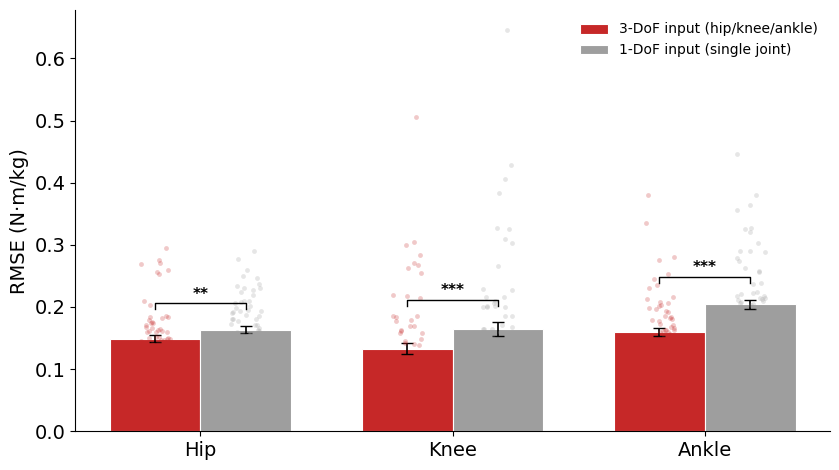

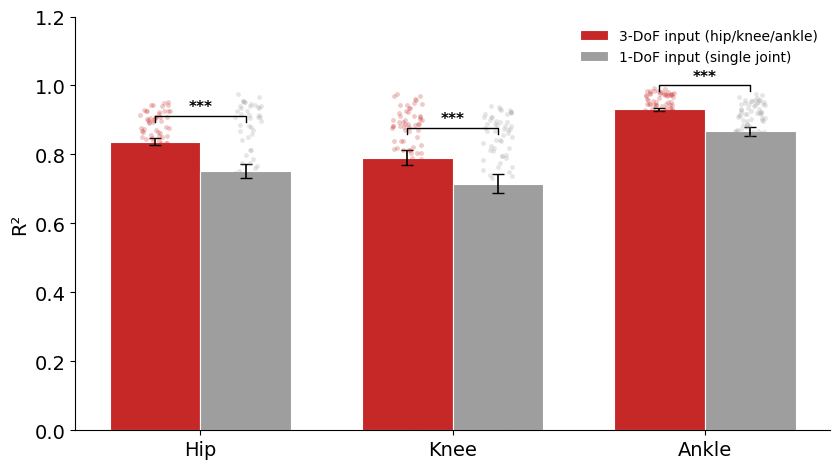

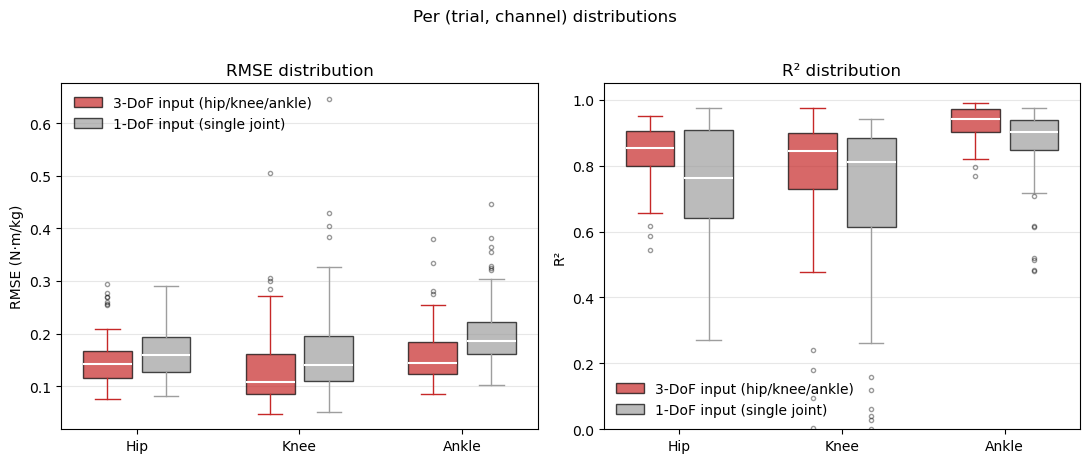

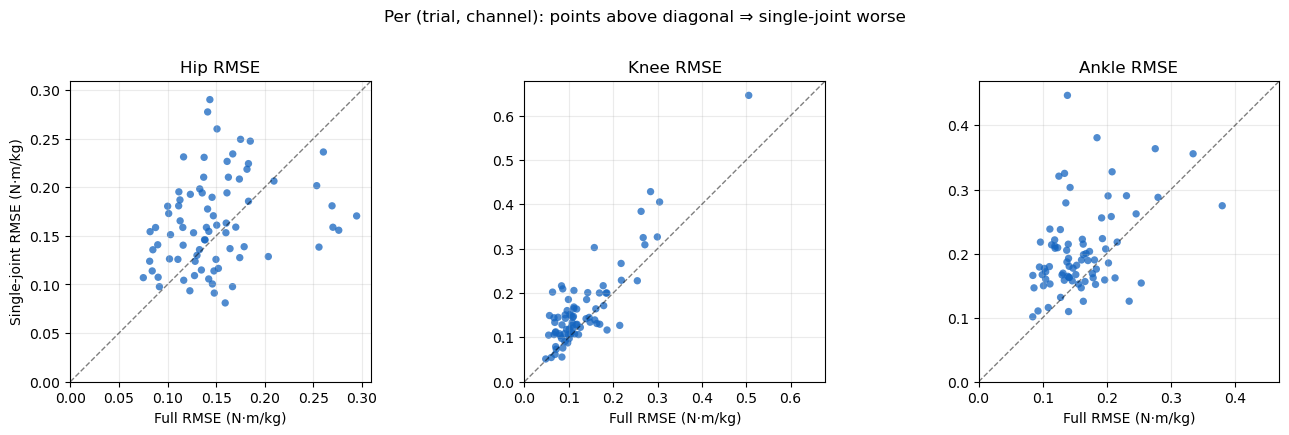

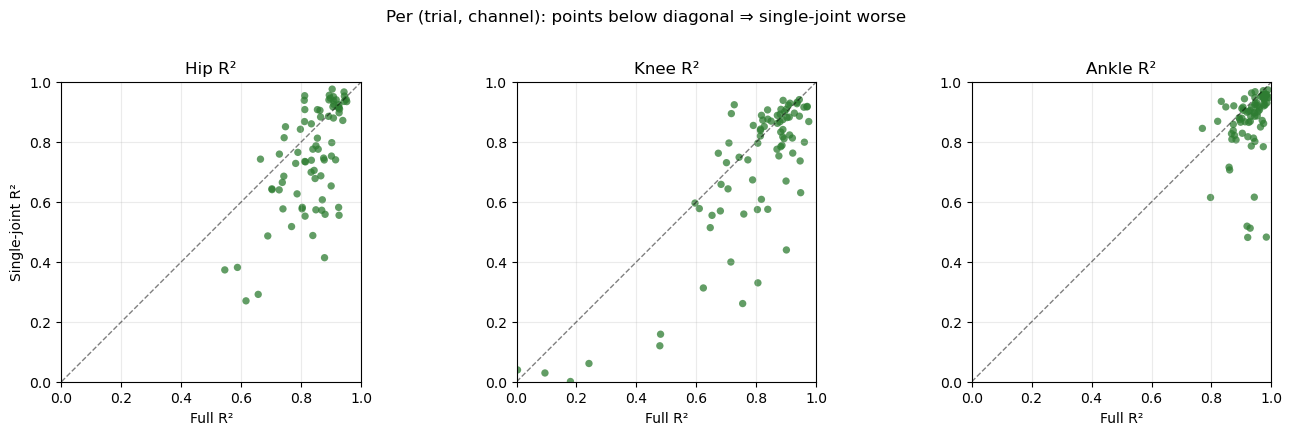

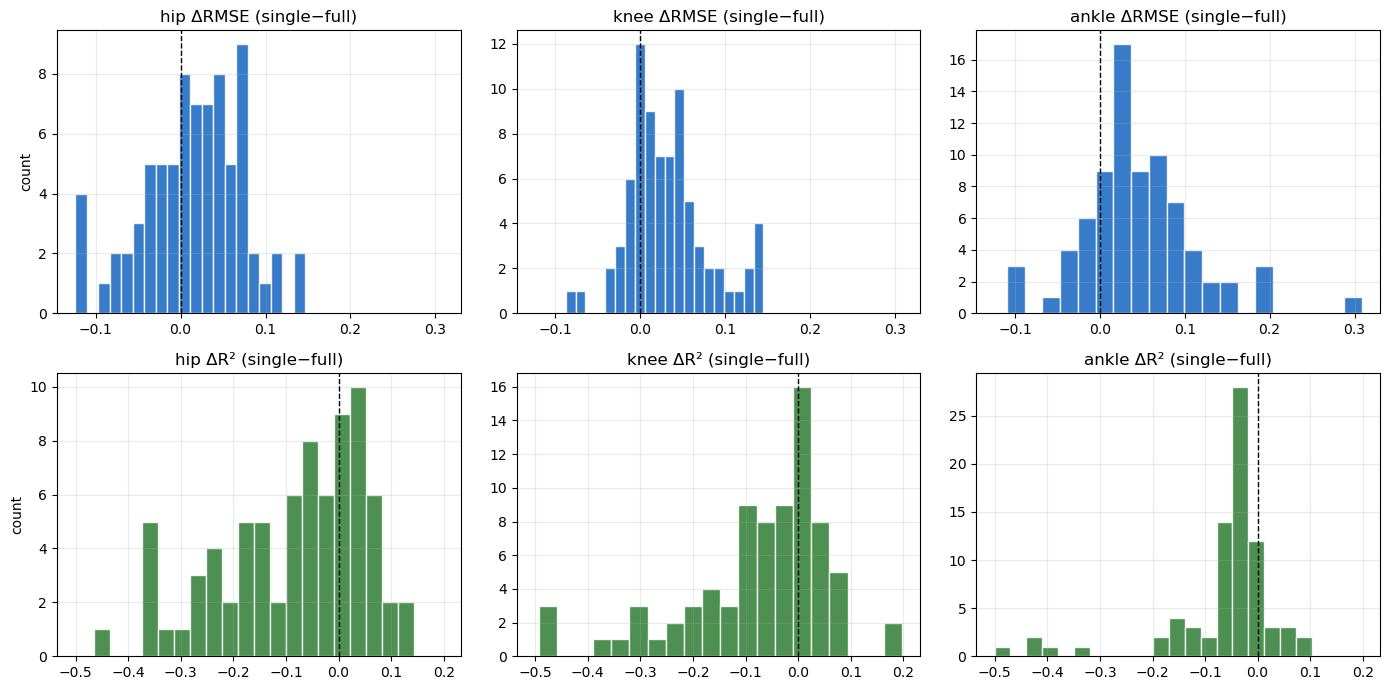

In [57]:
JOINT_ORDER = ['hip', 'knee', 'ankle']
COLORS = {'full': '#C62828', 'single': '#9E9E9E'}  # red = 3-DoF, gray = 1-DoF
LABELS = {
    'full': '3-DoF input (hip/knee/ankle)',
    'single': '1-DoF input (single joint)',
}
TICK_FONTSIZE = 14
LABEL_FONTSIZE = 14


def _mean_sem(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    return float(np.mean(x)), float(np.std(x, ddof=1) / np.sqrt(x.size)) if x.size > 1 else 0.0


def p_to_stars(p: float) -> str:
    """Standard star notation from a p-value (empty string if n.s.)."""
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def annotate_pair_significance(ax, x_left, x_right, y_top, p, h_frac=0.04):
    """Draw a bracket + stars between a pair of bars."""
    stars = p_to_stars(p)
    if not stars:
        return
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    h = span * h_frac
    y = y_top + h
    ax.plot([x_left, x_left, x_right, x_right], [y, y + h * 0.35, y + h * 0.35, y],
            color='k', lw=1.0, clip_on=False)
    ax.text((x_left + x_right) / 2, y + h * 0.45, stars,
            ha='center', va='bottom', fontsize=11, fontweight='bold', clip_on=False)
    # Make room for the annotation
    ax.set_ylim(y0, max(y1, y + h * 1.8))


def plot_joint_metric_bars(
    metric_full: str,
    metric_single: str,
    ylabel: str,
    title: str,
    p_col: str,
    ylim=None,
    legend_loc: str = 'best',
):
    """Grouped bars: per joint, full (red) vs single (gray), with Wilcoxon stars."""
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    x = np.arange(len(JOINT_ORDER), dtype=float)
    width = 0.36

    means_full, sems_full, means_single, sems_single = [], [], [], []
    for joint in JOINT_ORDER:
        g = paired[paired['joint'] == joint]
        m, s = _mean_sem(g[metric_full])
        means_full.append(m); sems_full.append(s)
        m, s = _mean_sem(g[metric_single])
        means_single.append(m); sems_single.append(s)

    ax.bar(
        x - width / 2, means_full, width, yerr=sems_full, capsize=4,
        color=COLORS['full'], edgecolor='white', linewidth=0.8,
        label=LABELS['full'], error_kw={'elinewidth': 1.2},
    )
    ax.bar(
        x + width / 2, means_single, width, yerr=sems_single, capsize=4,
        color=COLORS['single'], edgecolor='white', linewidth=0.8,
        label=LABELS['single'], error_kw={'elinewidth': 1.2},
    )

    # Light strip of paired points (jittered) for each joint
    rng = np.random.default_rng(0)
    for i, joint in enumerate(JOINT_ORDER):
        g = paired[paired['joint'] == joint]
        n = len(g)
        jitter = (rng.random(n) - 0.5) * 0.12
        ax.scatter(
            np.full(n, x[i] - width / 2) + jitter, g[metric_full],
            s=12, c=COLORS['full'], alpha=0.25, zorder=2, linewidths=0,
        )
        ax.scatter(
            np.full(n, x[i] + width / 2) + jitter, g[metric_single],
            s=12, c=COLORS['single'], alpha=0.25, zorder=2, linewidths=0,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([j.capitalize() for j in JOINT_ORDER], fontsize=TICK_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    # ax.set_title(title)
    ax.legend(frameon=False, loc=legend_loc)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ylim is not None:
        ax.set_ylim(*ylim)

    # Significance brackets between each full vs single pair
    pmap = tests_by_joint.set_index('joint')[p_col].to_dict()
    for i, joint in enumerate(JOINT_ORDER):
        y_top = max(
            means_full[i] + (sems_full[i] or 0.0),
            means_single[i] + (sems_single[i] or 0.0),
        )
        annotate_pair_significance(
            ax, x[i] - width / 2, x[i] + width / 2, y_top, pmap.get(joint, np.nan),
        )

    plt.tight_layout()
    plt.show()
    return fig


plot_joint_metric_bars(
    'rmse_full', 'rmse_single',
    ylabel='RMSE (N·m/kg)',
    title='RMSE by joint: 3-DoF vs 1-DoF input',
    p_col='wilcoxon_p_rmse_single_worse',
)
plot_joint_metric_bars(
    'r2_full', 'r2_single',
    ylabel='R²',
    title='R² by joint: 3-DoF vs 1-DoF input',
    p_col='wilcoxon_p_r2_single_worse',
    ylim=(0, 1.2),
    legend_loc='upper right',
)

# Also: side-by-side boxplots (distributional view)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (m_full, m_single, ylab, title) in zip(
    axs,
    [
        ('rmse_full', 'rmse_single', 'RMSE (N·m/kg)', 'RMSE distribution'),
        ('r2_full', 'r2_single', 'R²', 'R² distribution'),
    ],
):
    data_full = [paired.loc[paired['joint'] == j, m_full].to_numpy() for j in JOINT_ORDER]
    data_single = [paired.loc[paired['joint'] == j, m_single].to_numpy() for j in JOINT_ORDER]
    pos = np.arange(len(JOINT_ORDER), dtype=float)
    bp1 = ax.boxplot(
        data_full, positions=pos - 0.18, widths=0.3, patch_artist=True,
        manage_ticks=False,
        boxprops=dict(facecolor=COLORS['full'], alpha=0.7),
        medianprops=dict(color='white', lw=1.5),
        whiskerprops=dict(color=COLORS['full']),
        capprops=dict(color=COLORS['full']),
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
    )
    bp2 = ax.boxplot(
        data_single, positions=pos + 0.18, widths=0.3, patch_artist=True,
        manage_ticks=False,
        boxprops=dict(facecolor=COLORS['single'], alpha=0.7),
        medianprops=dict(color='white', lw=1.5),
        whiskerprops=dict(color=COLORS['single']),
        capprops=dict(color=COLORS['single']),
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
    )
    ax.set_xticks(pos)
    ax.set_xticklabels([j.capitalize() for j in JOINT_ORDER])
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], [LABELS['full'], LABELS['single']], frameon=False)
    if ylab == 'R²':
        ax.set_ylim(0, 1.05)
fig.suptitle('Per (trial, channel) distributions', y=1.02)
plt.tight_layout()
plt.show()

# --- existing scatter / delta plots ---
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
for ax, joint in zip(axs, JOINT_ORDER):
    g = paired[paired['joint'] == joint]
    ax.scatter(g['rmse_full'], g['rmse_single'], c='#1565C0', s=28, alpha=0.75, edgecolors='none')
    lim = max(g['rmse_full'].max(), g['rmse_single'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Full RMSE (N·m/kg)')
    ax.set_title(f'{joint.capitalize()} RMSE')
    ax.grid(alpha=0.25)
axs[0].set_ylabel('Single-joint RMSE (N·m/kg)')
fig.suptitle('Per (trial, channel): points above diagonal ⇒ single-joint worse', y=1.02)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
for ax, joint in zip(axs, JOINT_ORDER):
    g = paired[paired['joint'] == joint]
    ax.scatter(g['r2_full'], g['r2_single'], c='#2E7D32', s=28, alpha=0.75, edgecolors='none')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Full R²')
    ax.set_title(f'{joint.capitalize()} R²')
    ax.grid(alpha=0.25)
axs[0].set_ylabel('Single-joint R²')
fig.suptitle('Per (trial, channel): points below diagonal ⇒ single-joint worse', y=1.02)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(2, 3, figsize=(14, 7), sharex='row')
for j, joint in enumerate(JOINT_ORDER):
    g = paired[paired['joint'] == joint]
    axs[0, j].axvline(0, color='k', ls='--', lw=1)
    axs[0, j].hist(g['delta_rmse'], bins=20, color='#1565C0', alpha=0.85, edgecolor='white')
    axs[0, j].set_title(f'{joint} ΔRMSE (single−full)')
    axs[0, j].grid(alpha=0.25)
    axs[1, j].axvline(0, color='k', ls='--', lw=1)
    axs[1, j].hist(g['delta_r2'], bins=20, color='#2E7D32', alpha=0.85, edgecolor='white')
    axs[1, j].set_title(f'{joint} ΔR² (single−full)')
    axs[1, j].grid(alpha=0.25)
axs[0, 0].set_ylabel('count')
axs[1, 0].set_ylabel('count')
plt.tight_layout(); plt.show()


## 4. Optional: subject-level paired means

Average over active side channels (and all trials) within subject×joint, then re-test — reduces channel/trial dependence.


In [55]:
subj = (
    paired.groupby(['subject', 'joint'], as_index=False)
    .agg(
        rmse_full=('rmse_full', 'mean'),
        rmse_single=('rmse_single', 'mean'),
        r2_full=('r2_full', 'mean'),
        r2_single=('r2_single', 'mean'),
        n_pairs=('trial', 'count'),
    )
)
subj['delta_rmse'] = subj['rmse_single'] - subj['rmse_full']
subj['delta_r2'] = subj['r2_single'] - subj['r2_full']
subj['single_worse_rmse'] = subj['delta_rmse'] > 0
subj['single_worse_r2'] = subj['delta_r2'] < 0

tests_subj = run_tests(subj, ['joint'])
print('Subject-level paired tests (one score per subject×joint):')
display(tests_subj.round(4))

print('\nVerdict @ subject level:')
for _, row in tests_subj.iterrows():
    print(
        f"  {row['joint']:5s}  RMSE worse p={row['wilcoxon_p_rmse_single_worse']:.3g}  "
        f"R² worse p={row['wilcoxon_p_r2_single_worse']:.3g}  "
        f"(n subjects={int(row['n'])})"
    )

display(subj.pivot_table(
    index='subject', columns='joint',
    values=['delta_rmse', 'delta_r2'], aggfunc='mean',
).round(4))


Subject-level paired tests (one score per subject×joint):


,joint,n,median_delta_rmse,mean_delta_rmse,cohen_d_rmse,wilcoxon_p_rmse_single_worse,ttest_p_rmse_single_worse,sig_rmse_wilcoxon,median_delta_r2,mean_delta_r2,cohen_d_r2,wilcoxon_p_r2_single_worse,ttest_p_r2_single_worse,sig_r2_wilcoxon
0,ankle,8,0.0462,0.0451,1.4523,0.0039,0.0023,True,-0.0477,-0.0630,-1.2823,0.0039,0.0042,True
1,hip,8,0.0221,0.0136,0.3687,0.1914,0.1659,False,-0.0882,-0.0830,-1.1617,0.0195,0.0067,True
2,knee,8,0.0256,0.0312,1.0833,0.0078,0.0091,True,-0.0535,-0.0733,-0.7216,0.0273,0.0403,True



Verdict @ subject level:
  ankle  RMSE worse p=0.00391  R² worse p=0.00391  (n subjects=8)
  hip    RMSE worse p=0.191  R² worse p=0.0195  (n subjects=8)
  knee   RMSE worse p=0.00781  R² worse p=0.0273  (n subjects=8)


delta_r2                 delta_rmse                
joint             ankle     hip    knee      ankle     hip    knee
subject                                                           
AB01_Jinwoo     -0.0216 -0.0765 -0.2920     0.0060  0.0290  0.0892
AB02_Oscar      -0.0215 -0.1189 -0.0999     0.0299  0.0008  0.0450
AB03_Ilseung    -0.0059  0.0063 -0.0191     0.0035 -0.0368  0.0147
AB04_Changseob  -0.0436 -0.0366 -0.0879     0.0359  0.0151  0.0429
AB05_Maria      -0.0517  0.0056 -0.0016     0.0565 -0.0401  0.0084
AB06_Jimin      -0.1197 -0.1836  0.0210     0.0718  0.0617 -0.0000
AB07_Amy        -0.1177 -0.0998 -0.0004     0.0725  0.0344  0.0131
AB08_Seokhyun   -0.1218 -0.1608 -0.1064     0.0848  0.0445  0.0365

## 5. Paper-ready outputs

Exports tables (CSV + LaTeX) and figures (PDF + PNG @ 300 dpi) to `analysis/paper_outputs/awinda/`.

Requires sections 1–3 (`paired`, `summary_joint`, `tests_by_joint`, `tests_by_channel`).


In [56]:
OUT_DIR = PROJECT_ROOT / 'analysis' / 'paper_outputs' / PAPER_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

PAPER_RC = {
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
}


def _save_table(df: pd.DataFrame, stem: str, caption: str = '') -> None:
    csv_path = OUT_DIR / f'{stem}.csv'
    tex_path = OUT_DIR / f'{stem}.tex'
    df.to_csv(csv_path, index=False)
    try:
        tex = df.to_latex(index=False, float_format='%.4f', caption=caption or None, label=f'tab:{stem}')
    except TypeError:
        tex = df.to_latex(index=False, float_format='%.4f')
        if caption:
            tex = f'% {caption}\n' + tex
    tex_path.write_text(tex)


# --- tables ---
table1 = summary_joint.copy()
table2 = tests_by_joint.copy()
table3 = tests_by_channel.copy()
table4 = paired[
    ['trial', 'subject', 'condition', 'joint', 'channel',
     'rmse_full', 'rmse_single', 'delta_rmse',
     'r2_full', 'r2_single', 'delta_r2']
].sort_values(['joint', 'trial', 'channel']).reset_index(drop=True)

# Compact overall row
table0 = pd.DataFrame([{
    'n_pairs': int(len(paired)),
    'n_trials': int(paired['trial'].nunique()),
    'n_subjects': int(paired['subject'].nunique()),
    'rmse_full_mean': float(paired['rmse_full'].mean()),
    'rmse_single_mean': float(paired['rmse_single'].mean()),
    'delta_rmse_median': float(paired['delta_rmse'].median()),
    'r2_full_mean': float(paired['r2_full'].mean()),
    'r2_single_mean': float(paired['r2_single'].mean()),
    'delta_r2_median': float(paired['delta_r2'].median()),
    'frac_single_worse_rmse': float(paired['single_worse_rmse'].mean()),
    'frac_single_worse_r2': float(paired['single_worse_r2'].mean()),
}])

for stem, df, cap in (
    ('table0_overall', table0, 'Overall paired full vs single-joint (after excludes).'),
    ('table1_summary_by_joint', table1, 'Per-joint mean metrics (trial×channel pairs).'),
    ('table2_tests_by_joint', table2, 'One-sided tests by joint: H1 single-joint worse than full.'),
    ('table3_tests_by_channel', table3, 'One-sided tests by channel.'),
    ('table4_paired', table4, 'All paired (trial, channel) rows.'),
):
    _save_table(df.round(4) if stem != 'table4_paired' else df, stem, caption=cap)

print(f'Paper outputs → {OUT_DIR}')
display(table0.round(4))
display(table1.round(4))
display(table2.round(4))

# --- figures (paper versions of section 3) ---
with plt.rc_context(PAPER_RC):
    # fig1: RMSE + R² grouped bars (red = 3-DoF, gray = 1-DoF)
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
    x = np.arange(len(JOINT_ORDER), dtype=float)
    width = 0.36
    for ax, m_full, m_single, ylab, title, p_col in (
        (axes[0], 'rmse_full', 'rmse_single', 'RMSE (N·m/kg)', 'RMSE',
         'wilcoxon_p_rmse_single_worse'),
        (axes[1], 'r2_full', 'r2_single', 'R²', 'R²',
         'wilcoxon_p_r2_single_worse'),
    ):
        mf, sf, ms, ss = [], [], [], []
        for joint in JOINT_ORDER:
            g = paired[paired['joint'] == joint]
            m, s = _mean_sem(g[m_full]); mf.append(m); sf.append(s)
            m, s = _mean_sem(g[m_single]); ms.append(m); ss.append(s)
        ax.bar(x - width / 2, mf, width, yerr=sf, capsize=3, color=COLORS['full'],
               edgecolor='white', linewidth=0.6, label=LABELS['full'])
        ax.bar(x + width / 2, ms, width, yerr=ss, capsize=3, color=COLORS['single'],
               edgecolor='white', linewidth=0.6, label=LABELS['single'])
        ax.set_xticks(x)
        ax.set_xticklabels([j.capitalize() for j in JOINT_ORDER], fontsize=TICK_FONTSIZE)
        ax.set_ylabel(ylab, fontsize=LABEL_FONTSIZE)
        ax.set_title(title)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        if ylab == 'R²':
            ax.set_ylim(0, 1.2)
        pmap = tests_by_joint.set_index('joint')[p_col].to_dict()
        for i, joint in enumerate(JOINT_ORDER):
            y_top = max(mf[i] + (sf[i] or 0.0), ms[i] + (ss[i] or 0.0))
            annotate_pair_significance(
                ax, x[i] - width / 2, x[i] + width / 2, y_top, pmap.get(joint, np.nan),
                h_frac=0.035,
            )
    axes[0].legend(frameon=False, loc='best')
    axes[1].legend(frameon=False, loc='upper right')
    fig.suptitle('Awinda: 3-DoF vs 1-DoF input', y=1.03, fontsize=11)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig1_summary_bars.{ext}')
    plt.close(fig)


    # fig2: RMSE scatter by joint
    fig, axs = plt.subplots(1, 3, figsize=(7.4, 2.6), sharey=False)
    for ax, joint in zip(axs, JOINT_ORDER):
        g = paired[paired['joint'] == joint]
        ax.scatter(g['rmse_full'], g['rmse_single'], c=COLORS['full'], s=18, alpha=0.7, edgecolors='none')
        lim = max(g['rmse_full'].max(), g['rmse_single'].max()) * 1.05
        ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('Full RMSE')
        ax.set_title(joint.capitalize())
        ax.grid(alpha=0.25)
    axs[0].set_ylabel('Single RMSE')
    fig.suptitle('RMSE: above diagonal ⇒ single-joint worse', y=1.05, fontsize=11)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig2_rmse_scatter.{ext}')
    plt.close(fig)

    # fig3: R² scatter by joint
    fig, axs = plt.subplots(1, 3, figsize=(7.4, 2.6), sharey=False)
    for ax, joint in zip(axs, JOINT_ORDER):
        g = paired[paired['joint'] == joint]
        ax.scatter(g['r2_full'], g['r2_single'], c='#2E7D32', s=18, alpha=0.7, edgecolors='none')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('Full R²')
        ax.set_title(joint.capitalize())
        ax.grid(alpha=0.25)
    axs[0].set_ylabel('Single R²')
    fig.suptitle('R²: below diagonal ⇒ single-joint worse', y=1.05, fontsize=11)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig3_r2_scatter.{ext}')
    plt.close(fig)

    # fig4: Δ histograms
    fig, axs = plt.subplots(2, 3, figsize=(7.4, 4.2), sharex='row')
    for j, joint in enumerate(JOINT_ORDER):
        g = paired[paired['joint'] == joint]
        axs[0, j].axvline(0, color='k', ls='--', lw=0.8)
        axs[0, j].hist(g['delta_rmse'], bins=18, color=COLORS['full'], alpha=0.85, edgecolor='white')
        axs[0, j].set_title(f'{joint} ΔRMSE')
        axs[0, j].grid(alpha=0.25)
        axs[1, j].axvline(0, color='k', ls='--', lw=0.8)
        axs[1, j].hist(g['delta_r2'], bins=18, color='#2E7D32', alpha=0.85, edgecolor='white')
        axs[1, j].set_title(f'{joint} ΔR²')
        axs[1, j].grid(alpha=0.25)
    axs[0, 0].set_ylabel('count')
    axs[1, 0].set_ylabel('count')
    fig.suptitle('Δ = single − full', y=1.02, fontsize=11)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig4_delta_hist.{ext}')
    plt.close(fig)

print('\nSaved files:')
for fp in sorted(OUT_DIR.glob('*')):
    print(f'  {fp.name}')


Paper outputs → /home/metamobility3/Jinwoo/os_kinetics/analysis/paper_outputs/awinda


,n_pairs,n_trials,n_subjects,rmse_full_mean,rmse_single_mean,delta_rmse_median,r2_full_mean,r2_single_mean,delta_r2_median,frac_single_worse_rmse,frac_single_worse_r2
0,234,39,8,0.1469,0.1775,0.0289,0.8523,0.7778,-0.0421,0.735,0.7393


,joint,n,rmse_full_mean,rmse_single_mean,delta_rmse_median,delta_rmse_mean,frac_single_worse_rmse,r2_full_mean,r2_single_mean,delta_r2_median,delta_r2_mean,frac_single_worse_r2
0,ankle,78,0.1594,0.2042,0.0356,0.0448,0.8077,0.9305,0.8672,-0.0351,-0.0632,0.8590
1,hip,78,0.1487,0.1637,0.0211,0.0150,0.6410,0.8363,0.7510,-0.0604,-0.0853,0.6923
2,knee,78,0.1327,0.1645,0.0245,0.0318,0.7564,0.7903,0.7152,-0.0374,-0.0751,0.6667


,joint,n,median_delta_rmse,mean_delta_rmse,cohen_d_rmse,wilcoxon_p_rmse_single_worse,ttest_p_rmse_single_worse,sig_rmse_wilcoxon,median_delta_r2,mean_delta_r2,cohen_d_r2,wilcoxon_p_r2_single_worse,ttest_p_r2_single_worse,sig_r2_wilcoxon
0,ankle,78,0.0356,0.0448,0.6671,0.0000,0.000,True,-0.0351,-0.0632,-0.5857,0.0,0.0,True
1,hip,78,0.0211,0.0150,0.2569,0.0073,0.013,True,-0.0604,-0.0853,-0.6240,0.0,0.0,True
2,knee,78,0.0245,0.0318,0.6711,0.0000,0.000,True,-0.0374,-0.0751,-0.5439,0.0,0.0,True



Saved files:
  fig1_id_per_joint.pdf
  fig1_id_per_joint.png
  fig1_summary_bars.pdf
  fig1_summary_bars.png
  fig2_ik_per_joint.pdf
  fig2_ik_per_joint.png
  fig2_rmse_scatter.pdf
  fig2_rmse_scatter.png
  fig3_r2_by_task.pdf
  fig3_r2_by_task.png
  fig3_r2_scatter.pdf
  fig3_r2_scatter.png
  fig4_delta_hist.pdf
  fig4_delta_hist.png
  fig4_exemplar_id_timeseries.pdf
  fig4_exemplar_id_timeseries.png
  table0_overall.csv
  table0_overall.tex
  table1_id_per_joint.csv
  table1_id_per_joint.tex
  table1_summary_by_joint.csv
  table1_summary_by_joint.tex
  table2_ik_per_joint.csv
  table2_ik_per_joint.tex
  table2_tests_by_joint.csv
  table2_tests_by_joint.tex
  table3_id_per_trial.csv
  table3_id_per_trial.tex
  table3_tests_by_channel.csv
  table3_tests_by_channel.tex
  table4_ik_per_trial.csv
  table4_ik_per_trial.tex
  table4_paired.csv
  table4_paired.tex
  table5_combined_per_trial.csv
  table5_combined_per_trial.tex
  table6_overall_summary.csv
  table6_overall_summary.tex
